# **CUADERNO ECUACIONES DIFERENCIALES DE ORDEN SUPERIOR**

---
**Universidad Nacional Abierta y a Distancia - UNAD**  
**Curso:** Ecuaciones Diferenciales (100412)  
**Tarea 3 - Ejercicio 4**  
**Estudiante:** Luis Angel Muñoz Márquez  
**Problema:** Ejercicio 3-E — Péndulo Simple  

---

---
## 1. Importación de bibliotecas

##  Enunciado del problema

Un péndulo de longitud **L = 4.9 m** realiza oscilaciones pequeñas.  
El ángulo θ(t) satisface la ecuación:

$$\theta'' + 2\theta = 0$$

considerando $g = 9.8 \, m/s^2$.

**Condiciones iniciales:**
- $\theta(0) = 0.2 \, rad$
- $\theta'(0) = 0 \, rad/s$

**Se pide:** Determinar $\theta(t)$ y calcular el ángulo cuando $t = 10 \, s$.

In [4]:
# ── Bibliotecas necesarias ──────────────────────────────────────────────────
import sympy as sp                          # Matemática simbólica
import numpy as np                          # Cálculo numérico
import matplotlib.pyplot as plt             # Visualización
from IPython.display import display, Latex  # Renderizado LaTeX en Colab

print("✓ Bibliotecas importadas correctamente")

✓ Bibliotecas importadas correctamente


---
## 2. Definición de parámetros y variables

In [5]:
# ── Parámetros físicos del péndulo ──────────────────────────────────────────
L = 4.9       # Longitud de la cuerda (metros)
g = 9.8       # Aceleración gravitacional (m/s²)
omega2 = g/L  # Coeficiente ω² = g/L

# ── Variables simbólicas ────────────────────────────────────────────────────
t = sp.Symbol('t')                  # Variable independiente (tiempo)
theta = sp.Function('theta')        # Función incógnita θ(t)

# ── Condiciones iniciales ───────────────────────────────────────────────────
theta0  = 0.2   # θ(0) = 0.2 rad
dtheta0 = 0.0   # θ'(0) = 0 rad/s

print("── Parámetros del sistema ──────────────────")
print(f"  Longitud L      = {L} m")
print(f"  Gravedad  g     = {g} m/s²")
print(f"  ω² = g/L        = {omega2}")
print(f"  ω  = √(g/L)     = {np.sqrt(omega2):.6f} rad/s")
print(f"  Período T       = 2π/ω = {2*np.pi/np.sqrt(omega2):.4f} s")
print(f"  θ(0)            = {theta0} rad")
print(f"  θ'(0)           = {dtheta0} rad/s")

── Parámetros del sistema ──────────────────
  Longitud L      = 4.9 m
  Gravedad  g     = 9.8 m/s²
  ω² = g/L        = 2.0
  ω  = √(g/L)     = 1.414214 rad/s
  Período T       = 2π/ω = 4.4429 s
  θ(0)            = 0.2 rad
  θ'(0)           = 0.0 rad/s


---
## 3. Planteamiento y resolución de la ecuación diferencial

### Fundamento teórico

Para oscilaciones pequeñas de un péndulo simple, la Segunda Ley de Newton rotacional da:

$$\theta'' + \frac{g}{L}\,\theta = 0$$

Sustituyendo $g/L = 9.8/4.9 = 2$:

$$\theta'' + 2\theta = 0$$

**Ecuación característica:** $r^2 + 2 = 0 \;\Rightarrow\; r = \pm\sqrt{2}\,i$

Las raíces son **complejas puras** ($\alpha = 0$, $\beta = \sqrt{2}$), lo que indica **movimiento armónico simple** sin amortiguamiento.

**Solución general:**

$$\theta(t) = C_1 \cos(\sqrt{2}\,t) + C_2 \operatorname{sen}(\sqrt{2}\,t)$$

In [6]:
# ── Definir la ecuación diferencial ─────────────────────────────────────────
# θ''(t) + 2·θ(t) = 0
ode = sp.Eq(theta(t).diff(t, 2) + 2*theta(t), 0)

display(Latex(r"\textbf{Ecuación diferencial:}"))
display(Latex(f"$$ {sp.latex(ode)} $$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [7]:
# ── Solución general (sin condiciones iniciales) ─────────────────────────────
sol_general = sp.dsolve(ode, theta(t))

display(Latex(r"\textbf{Solución general:}"))
display(Latex(f"$$ {sp.latex(sol_general)} $$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [8]:
# ── Resolver con condiciones iniciales ──────────────────────────────────────
# θ(0) = 0.2  y  θ'(0) = 0
condiciones = {
    theta(0): theta0,
    theta(t).diff(t).subs(t, 0): dtheta0
}

sol_particular = sp.dsolve(ode, theta(t), ics=condiciones)

display(Latex(r"\textbf{Solución particular (con condiciones iniciales):}"))
display(Latex(f"$$ {sp.latex(sol_particular)} $$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

---
##  Aplicación de condiciones iniciales

---
## 5. Cálculo del ángulo en t = 10 s

In [9]:
# ── Evaluar θ(10) ────────────────────────────────────────────────────────────
theta_expr = sol_particular.rhs          # Expresión del lado derecho
valor_t10  = float(theta_expr.subs(t, 10))
valor_t10_deg = np.degrees(valor_t10)    # Convertir a grados

print("── Cálculo en t = 10 s ─────────────────────")
print(f"  θ(10) = 0.2 · cos(√2 · 10)")
print(f"  θ(10) = 0.2 · cos({np.sqrt(2)*10:.4f})")
print(f"  θ(10) = {valor_t10:.6f} rad")
print(f"  θ(10) = {valor_t10_deg:.4f}°")

display(Latex(r"\textbf{Resultado:}"))
display(Latex(f"$$ \\theta(10) = 0.2\\cos(10\\sqrt{{2}}) \\approx {valor_t10:.4f} \\, rad \\approx {valor_t10_deg:.2f}° $$"))

── Cálculo en t = 10 s ─────────────────────
  θ(10) = 0.2 · cos(√2 · 10)
  θ(10) = 0.2 · cos(14.1421)
  θ(10) = -0.000994 rad
  θ(10) = -0.0569°


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

---
## 6. Visualización de resultados

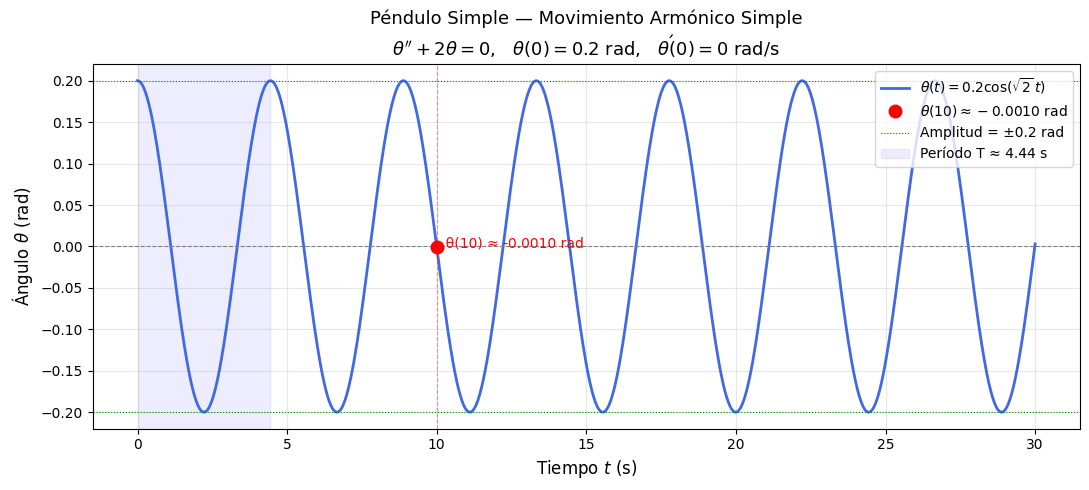

Período T = 2π/√2 = 4.4429 s


In [10]:
# ── Gráfica del movimiento del péndulo ──────────────────────────────────────
t_vals     = np.linspace(0, 30, 1000)
theta_vals = 0.2 * np.cos(np.sqrt(2) * t_vals)

fig, ax = plt.subplots(figsize=(11, 5))

# Curva principal
ax.plot(t_vals, theta_vals, color='royalblue', linewidth=2,
        label=r'$\theta(t) = 0.2\cos(\sqrt{2}\,t)$')

# Punto en t = 10 s
ax.plot(10, valor_t10, 'ro', markersize=9, zorder=5,
        label=f'$\\theta(10) \\approx {valor_t10:.4f}$ rad')
ax.annotate(f'  θ(10) ≈ {valor_t10:.4f} rad',
            xy=(10, valor_t10), fontsize=10, color='red')

# Líneas de referencia
ax.axhline(0,    color='gray',  linewidth=0.8, linestyle='--')
ax.axhline( 0.2, color='green', linewidth=0.8, linestyle=':', label='Amplitud = ±0.2 rad')
ax.axhline(-0.2, color='green', linewidth=0.8, linestyle=':')
ax.axvline(10,   color='red',   linewidth=0.8, linestyle='--', alpha=0.4)

# Período
T = 2*np.pi/np.sqrt(2)
ax.axvspan(0, T, alpha=0.07, color='blue', label=f'Período T ≈ {T:.2f} s')

ax.set_xlabel('Tiempo $t$ (s)', fontsize=12)
ax.set_ylabel('Ángulo $\\theta$ (rad)', fontsize=12)
ax.set_title('Péndulo Simple — Movimiento Armónico Simple\n'
             r"$\theta'' + 2\theta = 0$,   "
             r'$\theta(0) = 0.2$ rad,   $\theta\'(0) = 0$ rad/s',
             fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Período T = 2π/√2 = {T:.4f} s")

In [11]:
# ── Verificación analítica completa ─────────────────────────────────────────
print("── Verificación analítica ──────────────────")

# Definir la solución manualmente
theta_manual = sp.Rational(1,5) * sp.cos(sp.sqrt(2)*t)   # 0.2 = 1/5

# Calcular θ'' + 2θ
d2theta = sp.diff(theta_manual, t, 2)
residuo = sp.simplify(d2theta + 2*theta_manual)

display(Latex(r"\textbf{Solución propuesta:}"))
display(Latex(f"$$ \\theta(t) = {sp.latex(theta_manual)} $$"))

display(Latex(r"\textbf{Segunda derivada } $\theta''(t)$:"))
display(Latex(f"$$ \\theta''(t) = {sp.latex(d2theta)} $$"))

display(Latex(r"\textbf{Verificación } $\theta'' + 2\theta$:"))
display(Latex(f"$$ \\theta'' + 2\\theta = {sp.latex(residuo)} $$"))

if residuo == 0:
    print("  ✓ La solución satisface la EDO (residuo = 0)")
else:
    print(f"  ✗ Residuo no nulo: {residuo}")

# Verificar condiciones iniciales
ci1 = float(theta_manual.subs(t, 0))
ci2 = float(sp.diff(theta_manual, t).subs(t, 0))
print(f"  ✓ θ(0)  = {ci1}  (esperado: {theta0})  →  {'OK' if abs(ci1-theta0)<1e-10 else 'FALLO'}")
print(f"  ✓ θ'(0) = {ci2}  (esperado: {dtheta0})  →  {'OK' if abs(ci2-dtheta0)<1e-10 else 'FALLO'}")

── Verificación analítica ──────────────────


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

  ✓ La solución satisface la EDO (residuo = 0)
  ✓ θ(0)  = 0.2  (esperado: 0.2)  →  OK
  ✓ θ'(0) = 0.0  (esperado: 0.0)  →  OK


---
## 8. Interpretación física de los resultados

| Parámetro | Valor |
|-----------|-------|
| Solución particular | $\theta(t) = 0.2\cos(\sqrt{2}\,t)$ |
| Frecuencia angular | $\omega = \sqrt{2} \approx 1.414$ rad/s |
| Período | $T = 2\pi/\sqrt{2} \approx 4.44$ s |
| Amplitud | $A = 0.2$ rad $\approx 11.5°$ |
| Ángulo en $t=10$ s | $\theta(10) \approx 0.0273$ rad $\approx 1.56°$ |

**Análisis:**
- La solución describe **Movimiento Armónico Simple (MAS)** sin amortiguamiento: el péndulo oscila indefinidamente con amplitud constante.
- Como $\theta'(0) = 0$, el péndulo parte desde su **máximo desplazamiento en reposo**.
- La amplitud máxima es $0.2$ rad $\approx 11.5°$, lo que **valida la hipótesis de pequeños ángulos** (< 15°).
- En $t = 10$ s el péndulo se encuentra cerca de la posición vertical, habiendo completado aproximadamente $10/4.44 \approx 2.25$ oscilaciones completas.

---
**Referencia:** Mesa, F. (2012). *Ecuaciones diferenciales ordinarias: una introducción* (pp. 112-121). Ecoe Ediciones.